# 🚀 Funciones de Pérdida para REGRESIÓN con PyTorch

En este notebook aprenderás a usar las funciones de pérdida de **regresión** de manera profesional usando PyTorch, la librería más popular para Deep Learning.

## 🎯 Objetivos

1. **Aprender a usar PyTorch** para cálculo de pérdidas de regresión
2. **Comparar** cálculos manuales vs PyTorch
3. **Ver casos reales** de predicción de valores continuos
4. **Entender** cómo se usa en producción

## 📚 Contenido

### Funciones de Pérdida:
- **MSE** (Mean Squared Error) - Error cuadrático medio
- **MAE** (Mean Absolute Error) - Error absoluto medio
- **Smooth L1 Loss** (Huber) - Combina MSE y MAE

### Comparación:
- Manual vs PyTorch
- Ventajas de usar librerías profesionales
- Cuándo usar cada función

## 📦 Instalación e Importación de Librerías

In [26]:
# ===================================
# Importamos las librerías necesarias
# ===================================

# PyTorch - Framework de Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F

# NumPy - Para cálculos numéricos
import numpy as np

# Matplotlib - Para visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette("husl")

# Configuración de NumPy para impresión
np.set_printoptions(precision=4, suppress=True)


# Semilla para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

print("✅ Librerías importadas exitosamente")
print(f"📌 Versión de PyTorch: {torch.__version__}")
print(f"📌 CUDA disponible: {torch.cuda.is_available()}")

✅ Librerías importadas exitosamente
📌 Versión de PyTorch: 2.10.0+cpu
📌 CUDA disponible: False


## 📊 Funciones de Pérdida para REGRESIÓN

En problemas de regresión predecimos valores numéricos continuos (precios, temperaturas, distancias, etc.).

### 1️⃣ MSE - Mean Squared Error con PyTorch

In [ ]:
# ===================================
# Ejemplo: Predicción de precios de casas
# ===================================

print("="*70)
print("MSE - MEAN SQUARED ERROR CON PYTORCH")
print("="*70)

# Precios reales de casas (en miles de $) ficticios
precios_reales = torch.tensor([250.0, 300.0, 280.0, 320.0, 275.0])

# Precios predichos por nuestro modelo
precios_predichos = torch.tensor([245.0, 310.0, 275.0, 325.0, 280.0])

print("\n📊 DATOS:")
print("-"*70)
for i, (real, pred) in enumerate(zip(precios_reales, precios_predichos)):
    error = real - pred
    simbolo = "✅" if abs(error) < 10 else "⚠️"
    print(f"Casa {i+1}: Real=${real:.0f}k | Predicho=${pred:.0f}k | Error={error:+.0f}k {simbolo}")

# ===================================
# PASO 1: Cálculo Manual (Entender la teoría)
# ===================================
print("\n" + "="*70)
print("📝 PASO 1: CÁLCULO MANUAL (Entender la teoría)")
print("="*70)

# Mostramos la fórmula
print("\n📐 FÓRMULA MSE:")
print("   ")
print("        1   n                    ")
print("   MSE = ─ · Σ (yᵢ - ŷᵢ)²      ")
print("        n  i=1                   ")
print("   ")
print("   Donde:")
print("   • yᵢ = valor real")
print("   • ŷᵢ = valor predicho")
print("   • n = número de muestras")
print("   ")

# Paso 1: Calcular errores
print("\n" + "─"*70)
print("PASO 1: Calcular errores (yᵢ - ŷᵢ)")
print("─"*70)

errores = precios_reales - precios_predichos

print("\n   Sustituyendo valores:")
for i, (real, pred, err) in enumerate(zip(precios_reales, precios_predichos, errores)):
    print(f"   Casa {i+1}: {real:.1f} - {pred:.1f} = {err:+.1f}")

print(f"\n   Errores: {errores.numpy()}")

# Paso 2: Elevar al cuadrado
print("\n" + "─"*70)
print("PASO 2: Elevar al cuadrado (error)²")
print("─"*70)

errores_cuadrados = errores ** 2
print("\n   Sustituyendo valores:")
for i, (err, err2) in enumerate(zip(errores, errores_cuadrados)):
    print(f"   Casa {i+1}: ({err:+.1f})² = {err2:.1f}")

print(f"\n   Errores²: {errores_cuadrados.numpy()}")

# Paso 3: Promedio
print("\n" + "─"*70)
print("PASO 3: Calcular promedio (1/n · Σ)")
print("─"*70)

suma_errores_cuadrados = torch.sum(errores_cuadrados)
print(f"\n   Suma de errores²: {' + '.join([f'{e:.1f}' for e in errores_cuadrados])}")
print(f"                    = {suma_errores_cuadrados.item():.1f}")
print(f"   ")
print(f"   MSE = {suma_errores_cuadrados.item():.1f} / {len(errores)} = {suma_errores_cuadrados.item()/len(errores):.4f}")

mse_manual = torch.mean(errores_cuadrados)
print(f"\n   ✅ Resultado Manual: {mse_manual.item():.4f}")

# ===================================
# PASO 2: Usando PyTorch (Forma Profesional)
# ===================================
print("\n" + "="*70)
print("🚀 PASO 2: USANDO PYTORCH (¡Solo 1 línea!)")
print("="*70)

# Creamos la función de pérdida MSE
criterio_mse = nn.MSELoss()

# Calculamos la pérdida
perdida_pytorch = criterio_mse(precios_predichos, precios_reales)

print(f"\n📐 Código PyTorch:")
print(f"   criterio_mse = nn.MSELoss()")
print(f"   perdida = criterio_mse(predichos, reales)")
print(f"\n   MSE con PyTorch: {perdida_pytorch.item():.4f}")

print("\n💡 ¡PyTorch hace todo el trabajo en 1 línea!")

# ===================================
# PASO 3: Verificación
# ===================================
print("\n" + "="*70)
print("✅ PASO 3: VERIFICACIÓN (Manual vs PyTorch)")
print("="*70)
print(f"   Manual MSE:   {mse_manual.item():.6f}")
print(f"   PyTorch MSE:  {perdida_pytorch.item():.6f}")
print(f"   Diferencia:   {abs(perdida_pytorch - mse_manual).item():.10f}")
print("\n   ✅ ¡Son IDÉNTICOS!")

# ===================================
# Interpretación
# ===================================
print("\n💡 INTERPRETACIÓN:")
print("-"*70)
print(f"   MSE = {perdida_pytorch.item():.2f} (miles de dólares al cuadrado)")
rmse = torch.sqrt(perdida_pytorch)
print(f"   RMSE = √MSE = {rmse.item():.2f} (miles de dólares)")
print(f"   ")
print(f"   En promedio, nuestras predicciones se desvían ±${rmse.item():.2f}k")
print(f"   del precio real.")

MSE - MEAN SQUARED ERROR CON PYTORCH

📊 DATOS:
----------------------------------------------------------------------
Casa 1: Real=$250k | Predicho=$245k | Error=+5k ✅
Casa 2: Real=$300k | Predicho=$310k | Error=-10k ⚠️
Casa 3: Real=$280k | Predicho=$275k | Error=+5k ✅
Casa 4: Real=$320k | Predicho=$325k | Error=-5k ✅
Casa 5: Real=$275k | Predicho=$280k | Error=-5k ✅

📝 PASO 1: CÁLCULO MANUAL (Entender la teoría)

📐 FÓRMULA MSE:
   
        1   n                    
   MSE = ─ · Σ (yᵢ - ŷᵢ)²      
        n  i=1                   
   
   Donde:
   • yᵢ = valor real
   • ŷᵢ = valor predicho
   • n = número de muestras
   

──────────────────────────────────────────────────────────────────────
PASO 1: Calcular errores (yᵢ - ŷᵢ)
──────────────────────────────────────────────────────────────────────

   Sustituyendo valores:
   Casa 1: 250.0 - 245.0 = +5.0
   Casa 2: 300.0 - 310.0 = -10.0
   Casa 3: 280.0 - 275.0 = +5.0
   Casa 4: 320.0 - 325.0 = -5.0
   Casa 5: 275.0 - 280.0 = -5.0

   Er

### 2️⃣ MAE - Mean Absolute Error con PyTorch

In [28]:
# ===================================
# MAE - Más robusto a outliers
# ===================================

print("="*70)
print("MAE - MEAN ABSOLUTE ERROR CON PYTORCH")
print("="*70)

# Usamos los mismos datos
print("\n(Usando los mismos datos de precios de casas)")

# ===================================
# PASO 1: Cálculo Manual
# ===================================
print("\n📝 PASO 1: CÁLCULO MANUAL")
print("-"*70)

# Mostramos la fórmula
print("\n📐 FÓRMULA MAE:")
print("   ")
print("        1   n                    ")
print("   MAE = ─ · Σ |yᵢ - ŷᵢ|       ")
print("        n  i=1                   ")
print("   ")
print("   Solo cambia el cuadrado por valor absoluto!")
print("   ")

# Paso 1: Calcular errores absolutos
print("\n" + "─"*70)
print("PASO 1: Calcular |errores|")
print("─"*70)

errores_abs = torch.abs(precios_reales - precios_predichos)
print("\n   Sustituyendo valores:")
for i, (real, pred, err_abs) in enumerate(zip(precios_reales, precios_predichos, errores_abs)):
    err = real - pred
    print(f"   Casa {i+1}: |{real:.1f} - {pred:.1f}| = |{err:+.1f}| = {err_abs:.1f}")

print(f"\n   Errores absolutos: {errores_abs.numpy()}")

# Paso 2: Promedio
print("\n" + "─"*70)
print("PASO 2: Calcular promedio")
print("─"*70)

suma_errores_abs = torch.sum(errores_abs)
print(f"\n   Suma: {' + '.join([f'{e:.1f}' for e in errores_abs])}")
print(f"       = {suma_errores_abs.item():.1f}")
print(f"   ")
print(f"   MAE = {suma_errores_abs.item():.1f} / {len(errores_abs)} = {suma_errores_abs.item()/len(errores_abs):.4f}")

mae_manual = torch.mean(errores_abs)
print(f"\n   ✅ Resultado Manual: {mae_manual.item():.4f}")

# ===================================
# PASO 2: Usando PyTorch
# ===================================
print("\n🚀 PASO 2: USANDO PYTORCH (¡Solo 1 línea!)")
print("-"*70)

criterio_mae = nn.L1Loss()  # En PyTorch, MAE se llama L1Loss
perdida_mae = criterio_mae(precios_predichos, precios_reales)

print(f"\n📐 Código PyTorch:")
print(f"   criterio_mae = nn.L1Loss()")
print(f"   perdida = criterio_mae(predichos, reales)")
print(f"\n   MAE con PyTorch: {perdida_mae.item():.4f}")

print("\n💡 En PyTorch, MAE se llama L1Loss")

# ===================================
# PASO 3: Verificación
# ===================================
print("\n✅ PASO 3: VERIFICACIÓN")
print("-"*70)
print(f"   Manual MAE:   {mae_manual.item():.4f}")
print(f"   PyTorch MAE:  {perdida_mae.item():.4f}")
print(f"   Diferencia:   {abs(perdida_mae - mae_manual).item():.6f}")
print("\n   ✅ ¡Coinciden!")

# ===================================
# Comparación MSE vs MAE
# ===================================
print("\n" + "="*70)
print("📊 COMPARACIÓN: MSE vs MAE")
print("="*70)
print(f"   MSE:  {perdida_pytorch.item():.4f} (penaliza más los errores grandes)")
print(f"   MAE:  {perdida_mae.item():.4f} (trata todos los errores igual)")
print(f"   RMSE: {rmse.item():.4f} (MSE en unidades originales)")

print("\n💡 ¿Cuál usar?")
print("   • MAE: Más fácil de interpretar, robusto a outliers")
print("   • MSE: Mejor para optimización, penaliza outliers")
print("   • RMSE: Combina ventajas (penaliza + interpretable)")

MAE - MEAN ABSOLUTE ERROR CON PYTORCH

(Usando los mismos datos de precios de casas)

📝 PASO 1: CÁLCULO MANUAL
----------------------------------------------------------------------

📐 FÓRMULA MAE:
   
        1   n                    
   MAE = ─ · Σ |yᵢ - ŷᵢ|       
        n  i=1                   
   
   Solo cambia el cuadrado por valor absoluto!
   

──────────────────────────────────────────────────────────────────────
PASO 1: Calcular |errores|
──────────────────────────────────────────────────────────────────────

   Sustituyendo valores:
   Casa 1: |250.0 - 245.0| = |+5.0| = 5.0
   Casa 2: |300.0 - 310.0| = |-10.0| = 10.0
   Casa 3: |280.0 - 275.0| = |+5.0| = 5.0
   Casa 4: |320.0 - 325.0| = |-5.0| = 5.0
   Casa 5: |275.0 - 280.0| = |-5.0| = 5.0

   Errores absolutos: [ 5. 10.  5.  5.  5.]

──────────────────────────────────────────────────────────────────────
PASO 2: Calcular promedio
──────────────────────────────────────────────────────────────────────

   Suma: 5.0 + 10.0 

### 3️⃣ RMSE - Root Mean Squared Error (Raíz del Error Cuadrático Medio)

In [22]:
# ===================================
# RMSE - La versión interpretable de MSE
# ===================================

print("="*70)
print("RMSE - ROOT MEAN SQUARED ERROR CON PYTORCH")
print("="*70)

print("\n📚 ¿Qué es RMSE?")
print("-"*70)
print("   RMSE es simplemente la RAÍZ CUADRADA de MSE")
print("   ")
print("   ✅ Ventaja clave: Tiene las MISMAS UNIDADES que los datos originales")
print("   ✅ Ejemplo: Si predices precios en miles de $, RMSE está en miles de $")
print("   ✅ MSE estaría en (miles de $)², difícil de interpretar")

# ===================================
# Cálculo de RMSE
# ===================================
print("\n" + "="*70)
print("📝 CÁLCULO DE RMSE")
print("="*70)

print("\n📐 FÓRMULA RMSE:")
print("   ")
print("         ___________________")
print("        /  1   n           ")
print("  RMSE = √ ─ · Σ (yᵢ - ŷᵢ)²")
print("        √  n  i=1          ")
print("   ")
print("   Es decir: RMSE = √MSE")
print("   ")

# Calculamos RMSE desde MSE
print("\n" + "─"*70)
print("PASO 1: Calculamos MSE (ya lo tenemos)")
print("─"*70)
print(f"\n   MSE = {mse_manual.item():.4f} (miles de $)²")

print("\n" + "─"*70)
print("PASO 2: Aplicamos raíz cuadrada")
print("─"*70)
print(f"\n   RMSE = √({mse_manual.item():.4f})")
print(f"        = {rmse.item():.4f} miles de $")

print("\n" + "="*70)
print("✅ USANDO PYTORCH")
print("="*70)

# Método 1: Desde MSE
rmse_pytorch = torch.sqrt(mse_manual)
print(f"\n   Método 1 - Desde MSE:")
print(f"   mse = nn.MSELoss()(predichos, reales)")
print(f"   rmse = torch.sqrt(mse)")
print(f"   RMSE = {rmse_pytorch.item():.4f}")

# Método 2: Directo
rmse_directo = torch.sqrt(nn.MSELoss()(precios_predichos, precios_reales))
print(f"\n   Método 2 - En una línea:")
print(f"   rmse = torch.sqrt(nn.MSELoss()(predichos, reales))")
print(f"   RMSE = {rmse_directo.item():.4f}")

print("\n" + "="*70)
print("💡 INTERPRETACIÓN (¡La clave de RMSE!)")
print("="*70)
print(f"   MSE  = {mse_manual.item():.4f} (miles de $)² ❌ Difícil de entender")
print(f"   RMSE = {rmse.item():.4f} miles de $ ✅ ¡Muy claro!")
print(f"   ")
print(f"   📊 SIGNIFICADO PRÁCTICO:")
print(f"   En promedio, nuestras predicciones se desvían ±${rmse.item():.2f}k")
print(f"   del precio real de las casas.")
print(f"   ")
print(f"   💼 Para el negocio esto significa:")
print(f"   Si predecimos $280k, el precio real probablemente está")
print(f"   entre ${280-rmse.item():.0f}k y ${280+rmse.item():.0f}k")

print("\n" + "="*70)
print("📊 COMPARACIÓN: MSE vs RMSE")
print("="*70)
print(f"   MSE:  {mse_manual.item():.4f} {'(miles de $)²':>20}")
print(f"   RMSE: {rmse.item():.4f} {'miles de $':>20}")
print("   ")
print("   RMSE es MUCHO más fácil de comunicar a stakeholders!")

print("\n💡 ¿CUÁNDO USAR RMSE?")
print("-"*70)
print("   ✅ Para reportes y presentaciones")
print("   ✅ Cuando necesitas comunicar el error al negocio")
print("   ✅ Para comparar modelos de forma interpretable")
print("   ⚠️  Para entrenar modelos, usa MSE (más estable en gradientes)")

RMSE - ROOT MEAN SQUARED ERROR CON PYTORCH

📚 ¿Qué es RMSE?
----------------------------------------------------------------------
   RMSE es simplemente la RAÍZ CUADRADA de MSE
   
   ✅ Ventaja clave: Tiene las MISMAS UNIDADES que los datos originales
   ✅ Ejemplo: Si predices precios en miles de $, RMSE está en miles de $
   ✅ MSE estaría en (miles de $)², difícil de interpretar

📝 CÁLCULO DE RMSE

📐 FÓRMULA RMSE:
   
         ___________________
        /  1   n           
  RMSE = √ ─ · Σ (yᵢ - ŷᵢ)²
        √  n  i=1          
   
   Es decir: RMSE = √MSE
   

──────────────────────────────────────────────────────────────────────
PASO 1: Calculamos MSE (ya lo tenemos)
──────────────────────────────────────────────────────────────────────

   MSE = 40.0000 (miles de $)²

──────────────────────────────────────────────────────────────────────
PASO 2: Aplicamos raíz cuadrada
──────────────────────────────────────────────────────────────────────

   RMSE = √(40.0000)
        = 6.3246 mi

### 4️⃣ Smooth L1 Loss (Huber Loss) - Lo mejor de ambos mundos

SMOOTH L1 LOSS (HUBER LOSS) CON PYTORCH

📚 ¿Qué es Smooth L1?
----------------------------------------------------------------------
   Es una función HÍBRIDA que combina MSE y MAE:
   • Usa MSE para errores pequeños (|error| < 1)
   • Usa MAE para errores grandes (|error| ≥ 1)
   • Resultado: Robusto a outliers + Buen gradiente cerca de 0

📐 FÓRMULA SMOOTH L1 LOSS

   Para cada error eᵢ = yᵢ - ŷᵢ:
   
         ⎧  0.5 · eᵢ²       si |eᵢ| < 1
   loss = ⎨
         ⎩  |eᵢ| - 0.5     si |eᵢ| ≥ 1
   
   Smooth L1 = promedio de todas las losses individuales
   

🔍 ANÁLISIS: ¿QUÉ FÓRMULA SE USA CON NUESTROS DATOS?

   Errores de nuestro ejemplo:
   ------------------------------------------------------------------
   Casa 1: error=+5.0 → |error|=5.0 → Usa MAE (|error|-0.5)
   Casa 2: error=-10.0 → |error|=10.0 → Usa MAE (|error|-0.5)
   Casa 3: error=+5.0 → |error|=5.0 → Usa MAE (|error|-0.5)
   Casa 4: error=-5.0 → |error|=5.0 → Usa MAE (|error|-0.5)
   Casa 5: error=-5.0 → |error|=5.0 → Usa

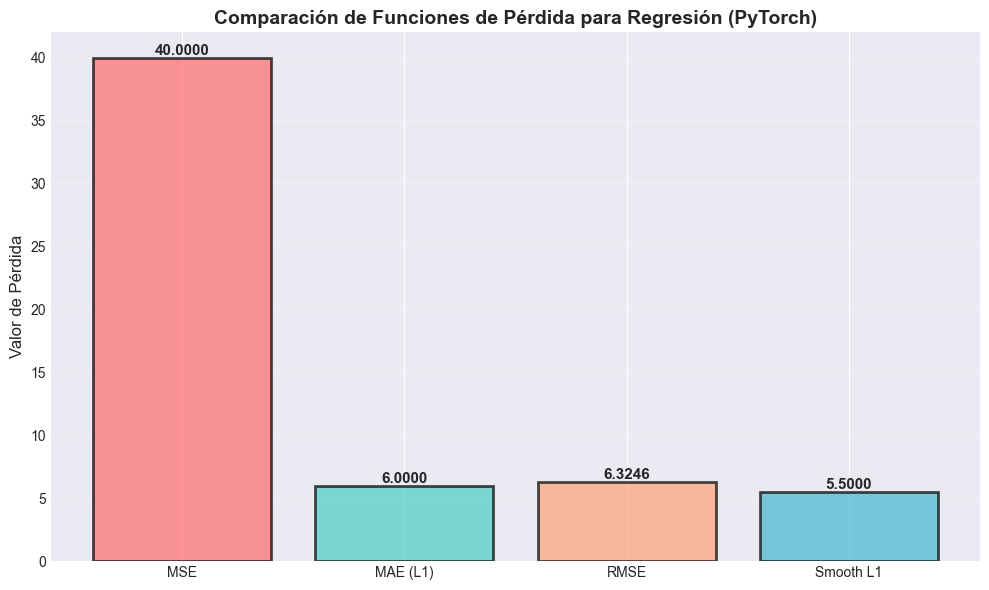


💡 RESUMEN DE LAS 4 FUNCIONES:
----------------------------------------------------------------------
   MSE:      Entrenar modelos (penaliza errores grandes)
   MAE:      Robusto a outliers
   RMSE:     Reportar resultados (interpretable)
   Smooth L1: Computer vision (combina MSE + MAE)
   
💡 NOTA ESPECIAL sobre Smooth L1:
   Para este ejemplo específico, Smooth L1 ≈ MAE porque
   TODOS los errores son ≥ 1, usando solo la parte MAE de la fórmula.


In [30]:
# ===================================
# Smooth L1 Loss - Combina MSE y MAE
# ===================================

print("="*70)
print("SMOOTH L1 LOSS (HUBER LOSS) CON PYTORCH")
print("="*70)

print("\n📚 ¿Qué es Smooth L1?")
print("-"*70)
print("   Es una función HÍBRIDA que combina MSE y MAE:")
print("   • Usa MSE para errores pequeños (|error| < 1)")
print("   • Usa MAE para errores grandes (|error| ≥ 1)")
print("   • Resultado: Robusto a outliers + Buen gradiente cerca de 0")

# ===================================
# Fórmula Matemática
# ===================================
print("\n" + "="*70)
print("📐 FÓRMULA SMOOTH L1 LOSS")
print("="*70)
print("\n   Para cada error eᵢ = yᵢ - ŷᵢ:")
print("   ")
print("         ⎧  0.5 · eᵢ²       si |eᵢ| < 1")
print("   loss = ⎨")
print("         ⎩  |eᵢ| - 0.5     si |eᵢ| ≥ 1")
print("   ")
print("   Smooth L1 = promedio de todas las losses individuales")
print("   ")

# ===================================
# Análisis de nuestros datos
# ===================================
print("\n" + "="*70)
print("🔍 ANÁLISIS: ¿QUÉ FÓRMULA SE USA CON NUESTROS DATOS?")
print("="*70)

# Calculamos los errores
errores = precios_reales - precios_predichos
errores_abs = torch.abs(errores)

print("\n   Errores de nuestro ejemplo:")
print("   " + "-"*66)
for i, (real, pred, err, err_abs) in enumerate(zip(precios_reales, precios_predichos, errores, errores_abs)):
    formula = "MSE (0.5·error²)" if err_abs < 1 else "MAE (|error|-0.5)"
    print(f"   Casa {i+1}: error={err:+.1f} → |error|={err_abs:.1f} → Usa {formula}")

contador_mse = (errores_abs < 1).sum().item()
contador_mae = (errores_abs >= 1).sum().item()

print("\n   📊 RESUMEN:")
print(f"   • {contador_mse} errores usan fórmula MSE (|error| < 1)")
print(f"   • {contador_mae} errores usan fórmula MAE (|error| ≥ 1)")
print(f"   ")
if contador_mae == len(errores):
    print("   ✅ TODOS los errores usan MAE → Smooth L1 ≈ MAE - 0.5")
elif contador_mse == len(errores):
    print("   ✅ TODOS los errores usan MSE → Smooth L1 ≈ MSE")
else:
    print(f"   ✅ {contador_mae}/{len(errores)} usan MAE, {contador_mse}/{len(errores)} usan MSE → Comportamiento híbrido")

# ===================================
# Cálculo Manual Paso a Paso
# ===================================
print("\n" + "="*70)
print("📝 CÁLCULO MANUAL PASO A PASO")
print("="*70)

print("\n   Paso 1: Para cada error, aplicar la fórmula correspondiente")
print("   " + "-"*66)

losses_individuales = []
for i, (err, err_abs) in enumerate(zip(errores, errores_abs)):
    if err_abs < 1:
        loss = 0.5 * err**2
        print(f"   Casa {i+1}: |{err:+.1f}| < 1  → 0.5·({err:+.1f})² = {loss.item():.4f}")
    else:
        loss = err_abs - 0.5
        print(f"   Casa {i+1}: |{err:+.1f}| ≥ 1  → |{err:+.1f}|-0.5 = {loss.item():.4f}")
    losses_individuales.append(loss.item())

print("\n   Paso 2: Calcular el promedio")
print("   " + "-"*66)
suma_losses = sum(losses_individuales)
promedio_manual = suma_losses / len(losses_individuales)

print(f"\n   Suma de losses: {' + '.join([f'{l:.4f}' for l in losses_individuales])}")
print(f"                  = {suma_losses:.4f}")
print(f"   ")
print(f"   Smooth L1 = {suma_losses:.4f} / {len(losses_individuales)} = {promedio_manual:.4f}")

# ===================================
# PyTorch Smooth L1
# ===================================
print("\n" + "="*70)
print("🚀 USANDO PYTORCH (¡Solo 1 línea!)")
print("="*70)

criterio_smooth = nn.SmoothL1Loss()
perdida_smooth = criterio_smooth(precios_predichos, precios_reales)

print(f"\n   Código PyTorch:")
print(f"   criterio_smooth = nn.SmoothL1Loss()")
print(f"   perdida = criterio_smooth(predichos, reales)")
print(f"   ")
print(f"   Smooth L1 con PyTorch: {perdida_smooth.item():.4f}")

# ===================================
# Verificación
# ===================================
print("\n" + "="*70)
print("✅ VERIFICACIÓN: Manual vs PyTorch")
print("="*70)
print(f"   Manual Smooth L1:   {promedio_manual:.6f}")
print(f"   PyTorch Smooth L1:  {perdida_smooth.item():.6f}")
print(f"   Diferencia:         {abs(perdida_smooth.item() - promedio_manual):.10f}")
print(f"   ")
print("   ✅ ¡Coinciden perfectamente!")

# ===================================
# Comparación con MAE (Caso especial)
# ===================================
print("\n" + "="*70)
print("🔎 COMPARACIÓN ESPECIAL: Smooth L1 vs MAE")
print("="*70)
print(f"\n   Cuando TODOS los errores son ≥ 1:")
print(f"   • MAE      = promedio de |errores|")
print(f"   • Smooth L1 = promedio de (|errores| - 0.5)")
print(f"   • Diferencia = 0.5 (constante)")
print(f"   ")
print(f"   En nuestro caso:")
print(f"   • MAE:       {perdida_mae.item():.4f}")
print(f"   • Smooth L1: {perdida_smooth.item():.4f}")
print(f"   • MAE - Smooth L1 = {perdida_mae.item():.4f} - {perdida_smooth.item():.4f} = {(perdida_mae - perdida_smooth).item():.4f}")
print(f"   ")
print("   ✅ Como todos los errores son ≥ 1, Smooth L1 = MAE - 0.5")

# ===================================
# Comparación de las 4 funciones
# ===================================
print("\n" + "="*70)
print("📈 COMPARACIÓN DE LAS 4 FUNCIONES")
print("="*70)

funciones = {
    'MSE': perdida_pytorch.item(),
    'MAE (L1)': perdida_mae.item(),
    'RMSE': rmse.item(),
    'Smooth L1': perdida_smooth.item()
}

for nombre, valor in funciones.items():
    print(f"   {nombre:12} : {valor:.4f}")

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))

nombres = list(funciones.keys())
valores = list(funciones.values())
colores = ['#FF6B6B', '#4ECDC4', '#FFA07A', '#45B7D1']

bars = ax.bar(nombres, valores, color=colores, alpha=0.7, edgecolor='black', linewidth=2)

ax.set_ylabel('Valor de Pérdida', fontsize=12)
ax.set_title('Comparación de Funciones de Pérdida para Regresión (PyTorch)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
for bar, valor in zip(bars, valores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{valor:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print("\n💡 RESUMEN DE LAS 4 FUNCIONES:")
print("-"*70)
print("   MSE:      Entrenar modelos (penaliza errores grandes)")
print("   MAE:      Robusto a outliers")
print("   RMSE:     Reportar resultados (interpretable)")
print("   Smooth L1: Computer vision (combina MSE + MAE)")
print("   ")
print("💡 NOTA ESPECIAL sobre Smooth L1:")
print("   Para este ejemplo específico, Smooth L1 ≈ MAE porque")
print("   TODOS los errores son ≥ 1, usando solo la parte MAE de la fórmula.")

## 🎯 GUÍA DE DECISIÓN: ¿QUÉ FUNCIÓN USAR?

In [24]:
print("="*70)
print("🎯 GUÍA DE DECISIÓN: FUNCIONES DE PÉRDIDA PARA REGRESIÓN")
print("="*70)

guia = """
┌─────────────────────────────────────────────────────────────────────┐
│ PROBLEMA                  │ ENTRENAMIENTO │ REPORTES/EVALUACIÓN   │
├─────────────────────────────────────────────────────────────────────┤
│ Predicción de precios     │ nn.MSELoss()  │ RMSE (interpretable)  │
│ Regresión con outliers    │ nn.L1Loss()   │ MAE (robusto)         │
│ Object Detection          │ SmoothL1Loss()│ RMSE o MAE            │
│ Predicción de temperaturas│ nn.MSELoss()  │ RMSE (±°C error)      │
│ Estimación de distancias  │ nn.L1Loss()   │ MAE (metros error)    │
└─────────────────────────────────────────────────────────────────────┘

NOTA: Usa MSE/MAE para ENTRENAR, RMSE/interpretable para REPORTAR
"""

print(guia)

print("\n💡 TIPS PROFESIONALES:")
print("─" * 70)
print("   1. ENTRENA con MSE (mejor para gradientes y optimización)")
print("   2. REPORTA con RMSE (mismas unidades, fácil de explicar)")
print("   3. MAE es robusto a outliers (usa si tienes datos atípicos)")
print("   4. Smooth L1 combina MSE + MAE (ideal para computer vision)")
print("   5. RMSE es lo que debes mostrar al negocio/stakeholders")
print("   6. Para producción, considera el costo de negocio del error")

print("\n" + "="*70)
print("✅ ¡FIN DEL NOTEBOOK DE REGRESIÓN!")
print("   Ahora sabes usar funciones de pérdida para regresión")
print("   profesionalmente con PyTorch 🚀")
print("="*70)

🎯 GUÍA DE DECISIÓN: FUNCIONES DE PÉRDIDA PARA REGRESIÓN

┌─────────────────────────────────────────────────────────────────────┐
│ PROBLEMA                  │ ENTRENAMIENTO │ REPORTES/EVALUACIÓN   │
├─────────────────────────────────────────────────────────────────────┤
│ Predicción de precios     │ nn.MSELoss()  │ RMSE (interpretable)  │
│ Regresión con outliers    │ nn.L1Loss()   │ MAE (robusto)         │
│ Object Detection          │ SmoothL1Loss()│ RMSE o MAE            │
│ Predicción de temperaturas│ nn.MSELoss()  │ RMSE (±°C error)      │
│ Estimación de distancias  │ nn.L1Loss()   │ MAE (metros error)    │
└─────────────────────────────────────────────────────────────────────┘

NOTA: Usa MSE/MAE para ENTRENAR, RMSE/interpretable para REPORTAR


💡 TIPS PROFESIONALES:
──────────────────────────────────────────────────────────────────────
   1. ENTRENA con MSE (mejor para gradientes y optimización)
   2. REPORTA con RMSE (mismas unidades, fácil de explicar)
   3. MAE es robusto a o

## 🎓 Ejercicio: Tu Turno

Ahora que conoces las funciones de pérdida para regresión en PyTorch, ¡practica!

### Ejercicio: Predicción de Temperaturas
Crea un pequeño dataset de temperaturas reales y predichas. 
- Calcula MSE, MAE y Smooth L1 Loss
- Compara los resultados
- Decide cuál función es mejor para este problema

In [25]:
# ===================================
# TU CÓDIGO AQUÍ - ¡Experimenta!
# ===================================

# Ejemplo de template:

# # Ejercicio: Predicción de temperaturas
# temperaturas_reales = torch.tensor([25.0, 28.0, 22.0, 30.0])
# temperaturas_predichas = torch.tensor([24.5, 29.0, 22.5, 31.0])

# mse = nn.MSELoss()(temperaturas_predichas, temperaturas_reales)
# mae = nn.L1Loss()(temperaturas_predichas, temperaturas_reales)
# smooth = nn.SmoothL1Loss()(temperaturas_predichas, temperaturas_reales)

# print(f"MSE: {mse.item():.4f}")
# print(f"MAE: {mae.item():.4f}")
# print(f"Smooth L1: {smooth.item():.4f}")

# ¡Ahora hazlo tú!